# Prac 05

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

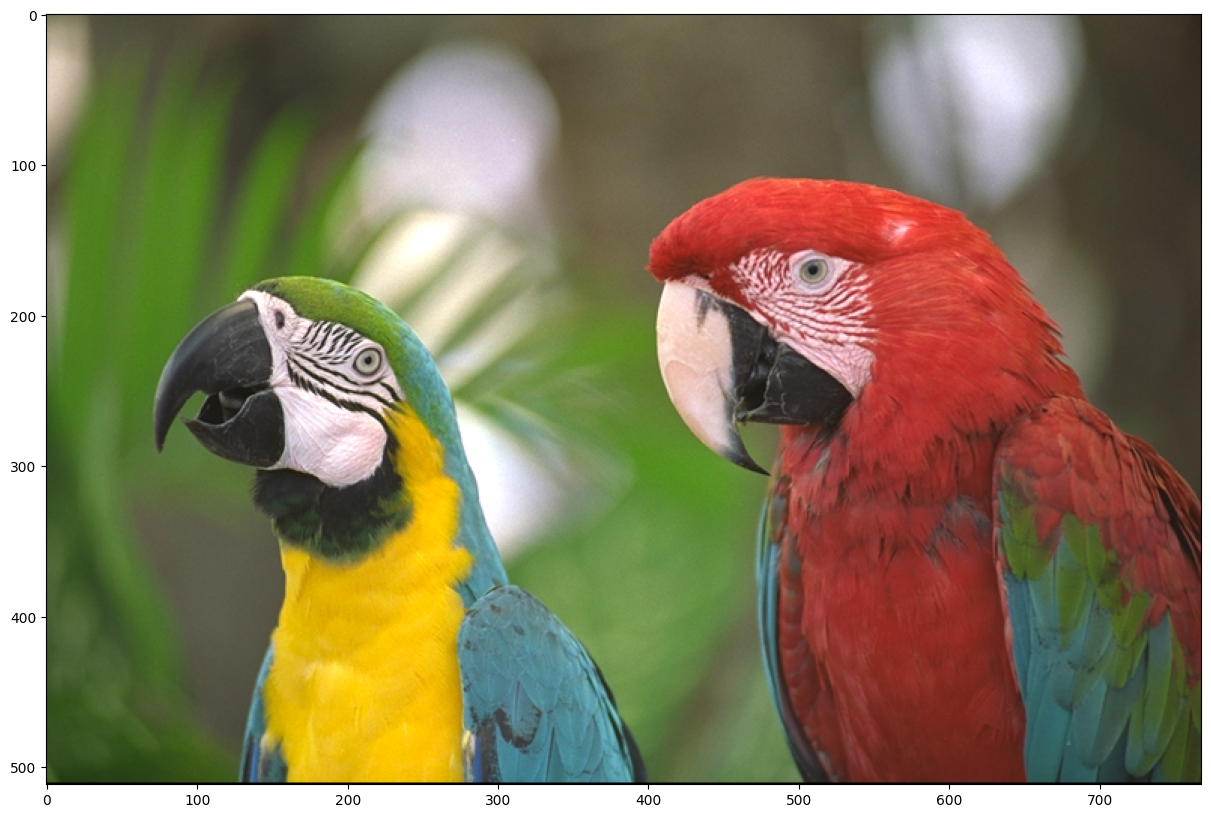

In [2]:
# Load image
img = cv2.imread('../data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)
plt.show()

Let's start with gray tones first.

In [3]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [4]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]
        
        # Apply quantization
        quantized[r, c, :] = new_pixel

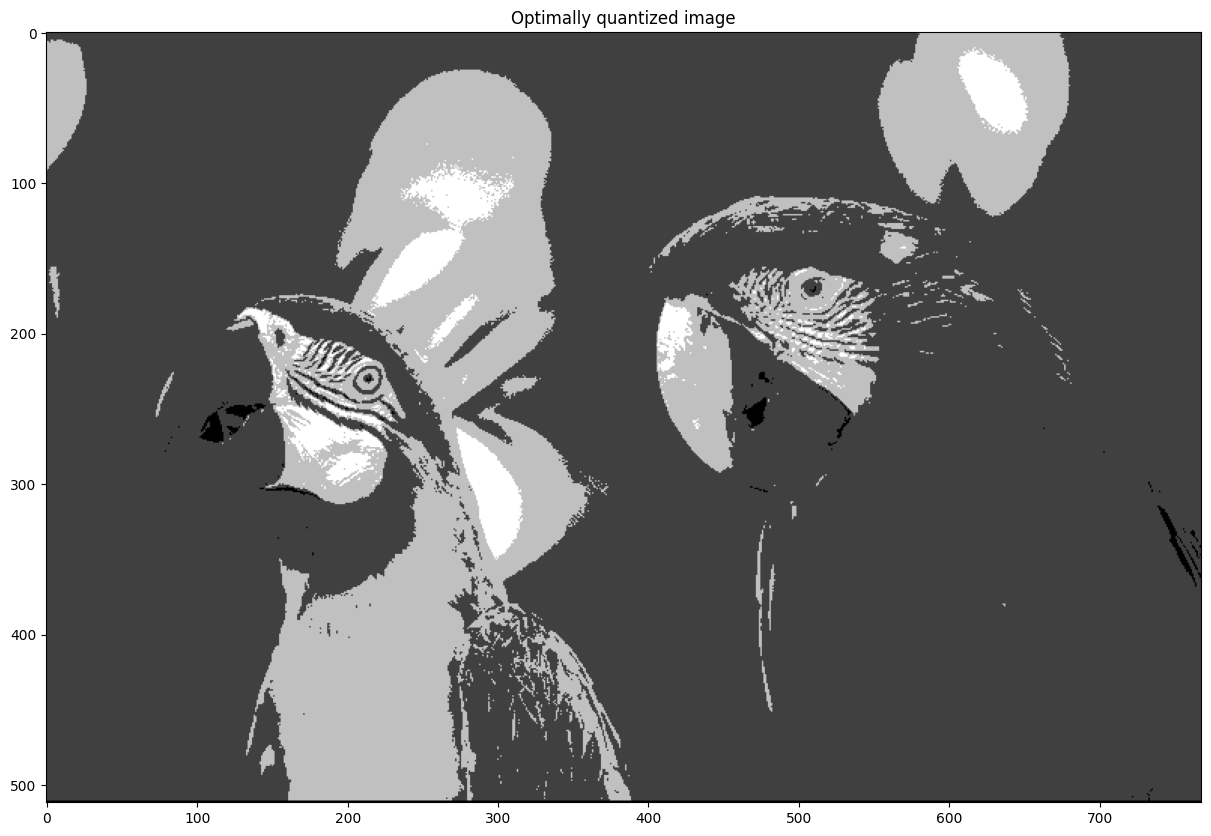

In [5]:
# Show quantized image (don't forget to cast back to uint8)
quantized_uint8 = np.clip(quantized, 0, 255).astype(np.uint8)
plt.imshow(quantized_uint8)
plt.title('Optimally quantized image')
plt.show()

In [6]:
# Compute average quantization error
avg_quant_error = np.mean(np.linalg.norm(img - quantized, axis=2))
print('Average quantization error:', avg_quant_error)

Average quantization error: 67.73236


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [7]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]
        
        # Compute quantization error
        quant_error = pixel - new_pixel
        
        # Diffuse the quantization error accroding to the FS diffusion matrix
        img_tmp[r, c + 1, :] += quant_error * 7 / 16
        img_tmp[r + 1, c - 1, :] += quant_error * 3 / 16
        img_tmp[r + 1, c, :] += quant_error * 5 / 16
        img_tmp[r + 1, c + 1, :] += quant_error * 1 / 16
        
        # Apply dithering
        dithering[r, c, :] = new_pixel

dithering = np.clip(dithering, 0, 255)

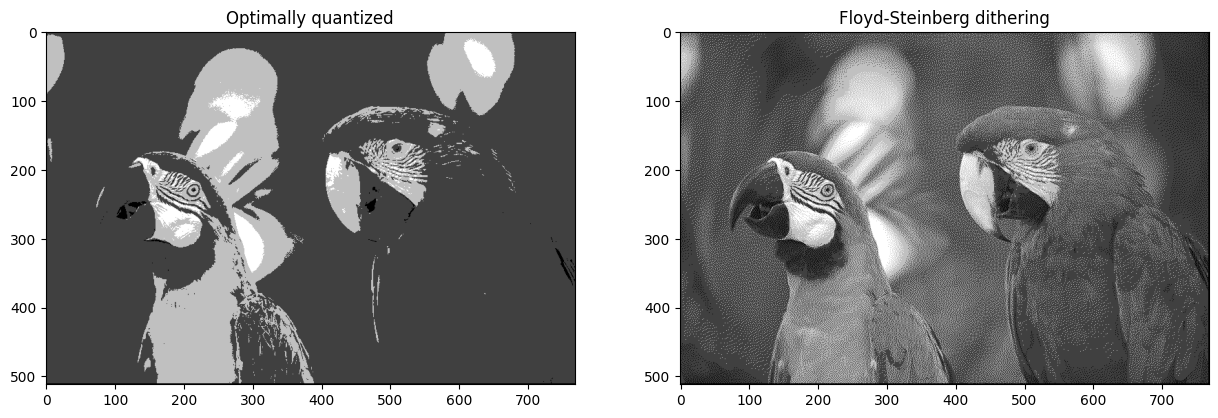

In [8]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized_uint8), plt.title('Optimally quantized')
plt.subplot(122), plt.imshow(dithering.astype(np.uint8)), plt.title('Floyd-Steinberg dithering')
plt.show()

In [9]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.linalg.norm(img - dithering, axis=2))
print('Average dithering error:', avg_dith_error)

Average dithering error: 82.233696


### Questions
* Which image has higher quantization error? Optimally quantized or dithered?

The dithered image typically has a slightly higher average pixel-wise quantization error because it intentionally redistributes that error to neighboring pixels.

* Which image looks better to you?

The dithered image looks better because the distributed error preserves local contrast and visual detail instead of forming large flat posterized regions.

* Can you repeat the same process using only two colours: black and white? Show me :-)

Yes. The extra cell above repeats the process with a black-and-white palette and shows that dithering is especially useful when the palette is very small.

In [ ]:
# Repeat the same process with black and white only
bw_colors = np.array([[0, 0, 0], [255, 255, 255]], dtype=np.float32)

bw_quantized = np.zeros_like(img)
bw_tmp = np.copy(img)
bw_dithered = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        new_pixel = bw_colors[np.argmin(np.linalg.norm(bw_colors - pixel, axis=1))]
        bw_quantized[r, c, :] = new_pixel

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        pixel = bw_tmp[r, c, :]
        new_pixel = bw_colors[np.argmin(np.linalg.norm(bw_colors - pixel, axis=1))]
        err = pixel - new_pixel
        bw_tmp[r, c + 1, :] += err * 7 / 16
        bw_tmp[r + 1, c - 1, :] += err * 3 / 16
        bw_tmp[r + 1, c, :] += err * 5 / 16
        bw_tmp[r + 1, c + 1, :] += err * 1 / 16
        bw_dithered[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(bw_quantized.astype(np.uint8)), plt.title('B/W quantized')
plt.subplot(122), plt.imshow(np.clip(bw_dithered, 0, 255).astype(np.uint8)), plt.title('B/W dithering')
plt.show()

In [ ]:
# Repeat the same process with black and white only
bw_colors = np.array([[0, 0, 0], [255, 255, 255]], dtype=np.float32)

bw_quantized = np.zeros_like(img)
bw_tmp = np.copy(img)
bw_dithered = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        new_pixel = bw_colors[np.argmin(np.linalg.norm(bw_colors - pixel, axis=1))]
        bw_quantized[r, c, :] = new_pixel

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        pixel = bw_tmp[r, c, :]
        new_pixel = bw_colors[np.argmin(np.linalg.norm(bw_colors - pixel, axis=1))]
        err = pixel - new_pixel
        bw_tmp[r, c + 1, :] += err * 7 / 16
        bw_tmp[r + 1, c - 1, :] += err * 3 / 16
        bw_tmp[r + 1, c, :] += err * 5 / 16
        bw_tmp[r + 1, c + 1, :] += err * 1 / 16
        bw_dithered[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(bw_quantized.astype(np.uint8)), plt.title('B/W quantized')
plt.subplot(122), plt.imshow(np.clip(bw_dithered, 0, 255).astype(np.uint8)), plt.title('B/W dithering')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
pixels = np.reshape(img, (-1, 3))
kmeans = KMeans(n_clusters=16, n_init=10, random_state=42).fit(pixels)
colors = kmeans.cluster_centers_
colors

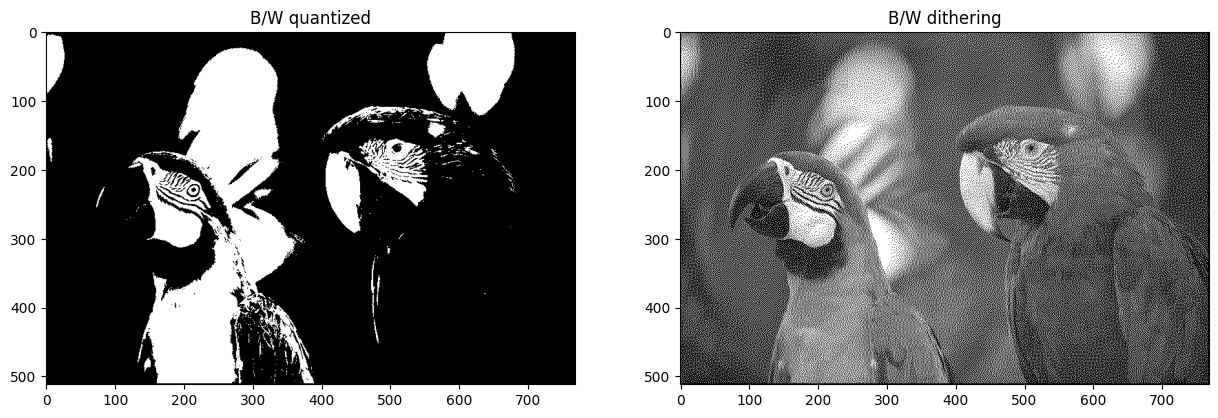

In [10]:
from sklearn.cluster import KMeans
pixels = np.reshape(img, (-1, 3))
kmeans = KMeans(n_clusters=16, n_init=10, random_state=42).fit(pixels)
colors = kmeans.cluster_centers_
colors

from sklearn.cluster import KMeans
pixels = np.reshape(img, (-1, 3))
kmeans = KMeans(n_clusters=16, n_init=10, random_state=42).fit(pixels)
colors = kmeans.cluster_centers_
colors

In [11]:
from sklearn.cluster import KMeans
pixels = np.reshape(img, (-1, 3))
kmeans = KMeans(n_clusters=16, n_init=10, random_state=42).fit(pixels)
colors = kmeans.cluster_centers_
colors

C:\Users\98389\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\98389\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


array([[ 62.747078,  61.84087 ,  45.547718],
       [171.2294  , 165.57825 , 157.22876 ],
       [ 86.19504 , 124.503716,  41.61697 ],
       [235.47247 , 187.97946 ,  11.265251],
       [153.35368 ,  55.293423,  48.16055 ],
       [239.5717  , 228.67563 , 231.05244 ],
       [ 89.69993 , 140.85162 , 147.82298 ],
       [ 63.160164,  97.06026 ,  95.01766 ],
       [113.272415,  45.42443 ,  37.27533 ],
       [ 75.84416 ,  88.97837 ,  50.16343 ],
       [211.76364 , 195.48389 , 194.05042 ],
       [ 42.689423,  39.73667 ,  32.767414],
       [137.21494 , 137.72354 , 113.85997 ],
       [100.53176 ,  96.29437 ,  72.69812 ],
       [208.14586 ,  69.23019 ,  58.95534 ],
       [111.01135 , 141.02728 ,  73.806   ]], dtype=float32)

Apply FS dithering the same way you did before.
* How does the result look like to you?
* What happens if we use 32 colours?
* And what happens if we use 256 colours?

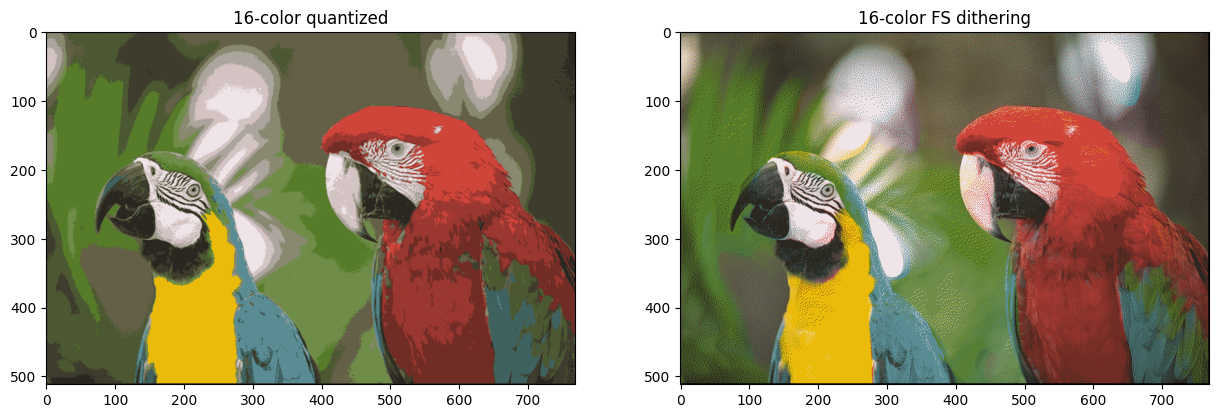

In [12]:
# Bonus: repeat FS dithering using the optimal 16-color k-means palette
km_quantized = np.zeros_like(img)
km_tmp = np.copy(img)
km_dithered = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        km_quantized[r, c, :] = new_pixel

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        pixel = km_tmp[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        err = pixel - new_pixel
        km_tmp[r, c + 1, :] += err * 7 / 16
        km_tmp[r + 1, c - 1, :] += err * 3 / 16
        km_tmp[r + 1, c, :] += err * 5 / 16
        km_tmp[r + 1, c + 1, :] += err * 1 / 16
        km_dithered[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(np.clip(km_quantized, 0, 255).astype(np.uint8)), plt.title('16-color quantized')
plt.subplot(122), plt.imshow(np.clip(km_dithered, 0, 255).astype(np.uint8)), plt.title('16-color FS dithering')
plt.show()

In [ ]:
# Bonus: repeat FS dithering using the optimal 16-color k-means palette
km_quantized = np.zeros_like(img)
km_tmp = np.copy(img)
km_dithered = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        km_quantized[r, c, :] = new_pixel

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        pixel = km_tmp[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        err = pixel - new_pixel
        km_tmp[r, c + 1, :] += err * 7 / 16
        km_tmp[r + 1, c - 1, :] += err * 3 / 16
        km_tmp[r + 1, c, :] += err * 5 / 16
        km_tmp[r + 1, c + 1, :] += err * 1 / 16
        km_dithered[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(np.clip(km_quantized, 0, 255).astype(np.uint8)), plt.title('16-color quantized')
plt.subplot(122), plt.imshow(np.clip(km_dithered, 0, 255).astype(np.uint8)), plt.title('16-color FS dithering')
plt.show()

In [ ]:
# Bonus: repeat FS dithering using the optimal 16-color k-means palette
km_quantized = np.zeros_like(img)
km_tmp = np.copy(img)
km_dithered = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        km_quantized[r, c, :] = new_pixel

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        pixel = km_tmp[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        err = pixel - new_pixel
        km_tmp[r, c + 1, :] += err * 7 / 16
        km_tmp[r + 1, c - 1, :] += err * 3 / 16
        km_tmp[r + 1, c, :] += err * 5 / 16
        km_tmp[r + 1, c + 1, :] += err * 1 / 16
        km_dithered[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(np.clip(km_quantized, 0, 255).astype(np.uint8)), plt.title('16-color quantized')
plt.subplot(122), plt.imshow(np.clip(km_dithered, 0, 255).astype(np.uint8)), plt.title('16-color FS dithering')
plt.show()

In [ ]:
# Bonus: repeat FS dithering using the optimal 16-color k-means palette
km_quantized = np.zeros_like(img)
km_tmp = np.copy(img)
km_dithered = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        km_quantized[r, c, :] = new_pixel

for r in range(1, rows - 1):
    for c in range(1, cols - 1):
        pixel = km_tmp[r, c, :]
        new_pixel = colors[np.argmin(np.linalg.norm(colors - pixel, axis=1))]
        err = pixel - new_pixel
        km_tmp[r, c + 1, :] += err * 7 / 16
        km_tmp[r + 1, c - 1, :] += err * 3 / 16
        km_tmp[r + 1, c, :] += err * 5 / 16
        km_tmp[r + 1, c + 1, :] += err * 1 / 16
        km_dithered[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(np.clip(km_quantized, 0, 255).astype(np.uint8)), plt.title('16-color quantized')
plt.subplot(122), plt.imshow(np.clip(km_dithered, 0, 255).astype(np.uint8)), plt.title('16-color FS dithering')
plt.show()